<a href="https://colab.research.google.com/github/AKASH1231961/PREDICTIVE_LAB/blob/main/predictive_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Lab_Exam_binary_classification_dataset.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [ ]:
# Display basic information about the DataFrame
print("\nDataFrame Information:")
display(df.info())


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB


None

In [ ]:
# Display descriptive statistics of the DataFrame
print("\nDescriptive statistics of the DataFrame:")
display(df.describe())


Descriptive statistics of the DataFrame:


,Feature1,Feature2
count,1020.000000,1020.000000
mean,11.436679,520.988235
std,313.061049,69.793442
min,1.250000,400.000000
25%,1.450000,464.000000
50%,1.637500,520.000000
75%,1.828125,584.000000
max,10000.000000,640.000000


In [ ]:
# Check for missing values in the 'Target' column
print("Missing values in 'Target' column before handling:")
display(df['Target'].isnull().sum())

# Display unique values in the 'Target' column
print("\nUnique values in 'Target' column before handling missing values:")
display(df['Target'].unique())

Missing values in 'Target' column before handling:


np.int64(20)


Unique values in 'Target' column before handling missing values:


array(['Yes', 'No', nan], dtype=object)

In [ ]:
# Drop rows where 'Target' is null
df.dropna(subset=['Target'], inplace=True)

# Encode the 'Target' column: 'Yes' to 1, 'No' to 0
df['Target'] = df['Target'].map({'Yes': 1, 'No': 0})

# Verify the changes
print("Missing values in 'Target' column after handling:")
display(df['Target'].isnull().sum())

print("\nUnique values in 'Target' column after encoding:")
display(df['Target'].unique())

print("\nDataFrame Information after handling missing values and encoding Target:")
display(df.info())

Missing values in 'Target' column after handling:


np.int64(0)


Unique values in 'Target' column after encoding:


array([1, 0])


DataFrame Information after handling missing values and encoding Target:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1000 non-null   float64
 1   Feature2  1000 non-null   int64  
 2   Target    1000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 31.2 KB


None

In [ ]:
# Identify the row with the maximum value in 'Feature1'
outlier_row = df[df['Feature1'] == df['Feature1'].max()]

print("Row with outlier in Feature1:")
display(outlier_row)

Row with outlier in Feature1:


,Feature1,Feature2,Target
132,10000.0,620,0


In [ ]:
# Remove the outlier row from the DataFrame
df = df[df['Feature1'] != df['Feature1'].max()]

print("DataFrame after removing outlier in Feature1:")
display(df.describe())

DataFrame after removing outlier in Feature1:


,Feature1,Feature2,Target
count,999.000000,999.000000,999.000000
mean,1.634547,521.109109,0.215215
std,0.220714,70.005347,0.411177
min,1.250000,400.000000,0.000000
25%,1.450000,464.000000,0.000000
50%,1.637500,520.000000,0.000000
75%,1.831250,584.000000,0.000000
max,2.000000,640.000000,1.000000


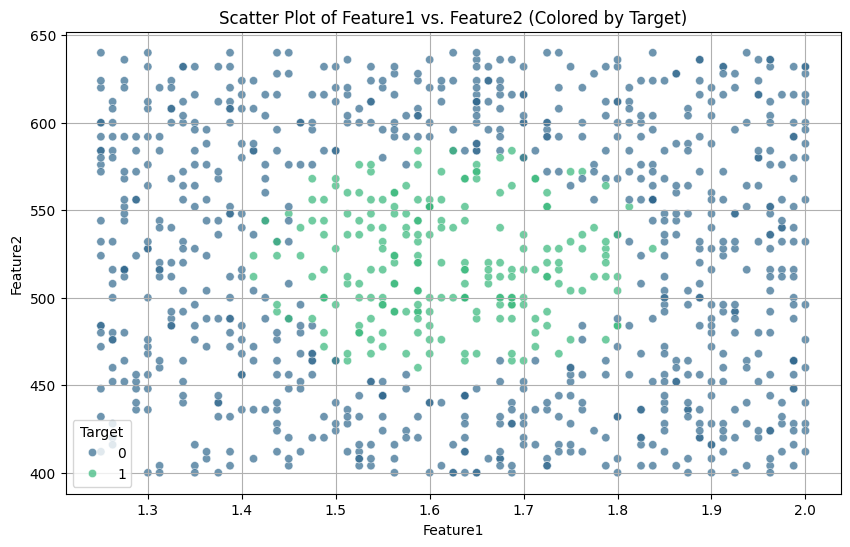

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Feature1 and Feature2, colored by Target
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Target', palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Feature1 vs. Feature2 (Colored by Target)')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.grid(True)
plt.show()

In [ ]:
# Separate features (X) and target (y)
X = df[['Feature1', 'Feature2']]
y = df['Target']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (999, 2)
Target (y) shape: (999,)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, model, title):
    # Set min and max values and give it some padding
    x_min, x_max = X.iloc[:, 0].min() - 0.1, X.iloc[:, 0].max() + 0.1
    y_min, y_max = X.iloc[:, 1].min() - 0.1, X.iloc[:, 1].max() + 0.1
    h = 0.01  # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training examples
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=20, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature1')
    plt.ylabel('Feature2')
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (699, 2)
X_test shape: (300, 2)
y_train shape: (699,)
y_test shape: (300,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree Classifier
# Using random_state for reproducibility
# You might consider class_weight='balanced' if imbalance is still an issue, similar to Logistic Regression
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test data
dt_y_pred = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Model Accuracy:", accuracy_score(y_test, dt_y_pred))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, dt_y_pred))

Decision Tree Model Accuracy: 0.9433333333333334

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96       240
           1       0.79      0.98      0.87        60

    accuracy                           0.94       300
   macro avg       0.89      0.96      0.92       300
weighted avg       0.95      0.94      0.95       300



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


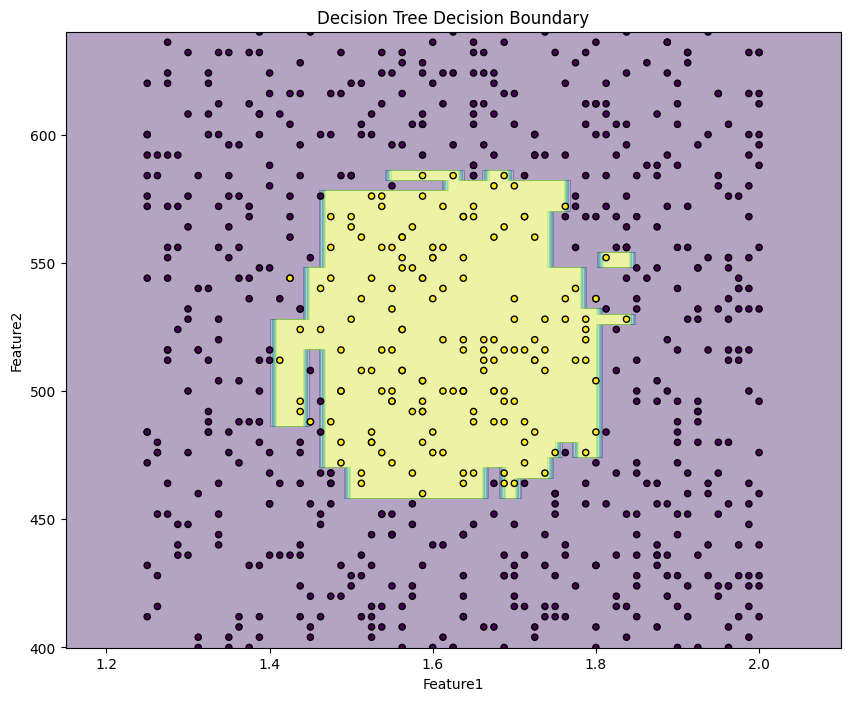

In [ ]:
# Plot the decision boundary for the Decision Tree model
# Reuse the previously defined plot_decision_boundary function
plot_decision_boundary(X_train, y_train, dt_model, "Decision Tree Decision Boundary")